In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import os

In [36]:
df = pd.read_csv('database/train_mod_tratado_anova.csv')

In [37]:
df.head(100)

,Fabricante_LAMBORGHINI,Idade,Ano,Km,Tipo_cambio_Tiptronic,Categoria_SUV,Volume_motor,Combustivel_Híbrido,Fabricante_HYUNDAI,Fabricante_BENTLEY,...,Airbags,Cor_Vermelho,Fabricante_FERRARI,Fabricante_VAZ,Fabricante_MAZDA,Fabricante_DODGE,Fabricante_MITSUBISHI,Categoria_Microonibus,Tipo_cambio_Variator,Preco
0,0,24,1999,122231.000000,0,0,1.6,0,0,0,...,4,0,0,0,0,0,0,0,0,1.0
1,0,7,2016,41000.000000,0,0,1.8,0,0,0,...,8,0,0,0,0,0,0,0,0,3.0
2,0,19,2004,328000.000000,0,0,2.3,0,0,0,...,0,0,0,0,0,0,0,0,0,3.0
3,0,9,2014,134400.000000,1,0,1.8,0,0,0,...,6,0,0,0,0,0,0,0,0,3.0
4,0,19,2004,176336.247138,0,1,3.3,0,0,0,...,2,0,0,0,0,0,0,0,0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0,10,2013,150000.000000,0,0,1.5,1,0,0,...,0,0,0,0,0,0,0,0,0,50.0
96,0,15,2008,135000.000000,0,0,1.5,1,0,0,...,6,0,0,0,0,0,0,0,0,50.0
97,0,15,2008,150000.000000,0,0,1.5,1,0,0,...,0,0,0,0,0,0,0,0,0,50.0
98,0,17,2006,140480.990804,0,0,1.3,0,0,0,...,2,0,0,0,0,0,0,0,0,50.0


In [38]:
# Removemos o topo 5% e a base 1% para evitar ruídos de preços irreais ou carros de luxo extremos
#q_low = df["Preco"].quantile(0.01)
#q_hi  = df["Preco"].quantile(0.95)
#df_filtered = df[(df["Preco"] < q_hi) & (df["Preco"] > q_low)].copy()

In [39]:
target = 'Preco'
feature_columns = [col for col in df.columns if col != target]

In [40]:
X = df[feature_columns].replace([np.inf, -np.inf], np.nan).fillna(0)
y = df[target]

In [41]:
print(f'Features usadas no treino: {len(feature_columns)}')
print(f'Valores ausentes em X: {int(X.isna().sum().sum())}')

Features usadas no treino: 47
Valores ausentes em X: 0


In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [43]:
# O dataset ja foi encodado e filtrado por ANOVA na analise exploratoria.
# Por isso, os modelos treinam diretamente em X.

In [44]:
param_grid_ridge = {
    "alpha": [0.1, 1.0, 10.0]
}
model_ridge = Ridge()
grid_ridge = GridSearchCV(model_ridge, param_grid_ridge, cv=3, scoring="r2", n_jobs=1)
grid_ridge.fit(X_train, y_train)
best_ridge = grid_ridge.best_estimator_

In [45]:
param_grid_rf = {
    "n_estimators": [50, 100],
    "max_depth": [10, 15]
}
model_rf = RandomForestRegressor(random_state=42)
grid_rf = GridSearchCV(model_rf, param_grid_rf, cv=3, scoring="r2", n_jobs=1)
grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_

In [46]:
param_grid_gb = {
    "n_estimators": [50, 100],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5]
}
model_gb = GradientBoostingRegressor(random_state=42)
grid_gb = GridSearchCV(model_gb, param_grid_gb, cv=3, scoring="r2", n_jobs=1)
grid_gb.fit(X_train, y_train)
best_gb = grid_gb.best_estimator_


In [47]:
models = {
    "Ridge Regression": best_ridge,
    "Random Forest": best_rf,
    "Gradient Boosting": best_gb
}

results = []
best_r2 = -np.inf
best_model_name = ""
best_model_instance = None

In [48]:
for name, model in models.items():
    y_pred = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results.append({"Modelo": name, "RMSE": rmse, "MAE": mae, "R2": r2})

    if r2 > best_r2:
        best_r2 = r2
        best_model_name = name
        best_model_instance = model

results_df = pd.DataFrame(results)
print("\n--- Resultados da Avaliação ---")
print(results_df)


--- Resultados da Avaliação ---
              Modelo          RMSE           MAE        R2
0   Ridge Regression  26499.509745  11009.498872  0.141811
1      Random Forest  18357.515557   6472.059859  0.588154
2  Gradient Boosting  20804.488167   8794.885149  0.471042



Gráfico 'comparacao_modelos_grid_search.png' gerado com sucesso.


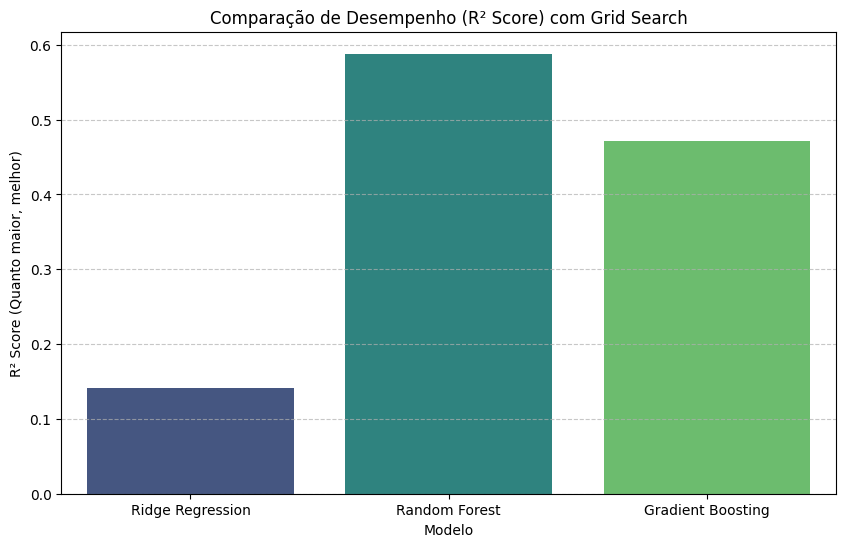

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x="Modelo", y="R2", data=results_df, hue="Modelo", palette="viridis", legend=False)
plt.title("Comparação de Desempenho (R² Score) com Grid Search")
plt.ylabel("R² Score (Quanto maior, melhor)")
plt.grid(axis="y", linestyle="--", alpha=0.7)
#plt.savefig("comparacao_modelos_grid_search.png")
print("\nGráfico 'comparacao_modelos_grid_search.png' gerado com sucesso.")

In [50]:
if best_model_instance:
    os.makedirs("models", exist_ok=True)
    model_filename = "models/best_regression_model.pkl"
    features_filename = "models/model_feature_columns.pkl"
    joblib.dump(best_model_instance, model_filename)
    joblib.dump(feature_columns, features_filename)
    print(f"\nO melhor modelo ({best_model_name}) foi salvo como '{model_filename}'.")
    print(f"Features do modelo salvas como '{features_filename}'.")


O melhor modelo (Random Forest) foi salvo como 'models/best_regression_model.pkl'.
Features do modelo salvas como 'models/model_feature_columns.pkl'.


In [51]:
exemplo = X_test.iloc[[0]]
pred = best_model_instance.predict(exemplo)
print(f"Valor Real: {y_test.iloc[0]:.2f} | Valor Predito: {pred[0]:.2f}")

Valor Real: 25716.00 | Valor Predito: 22098.14
